# 03 · Diagnostics, cross-validation & early stopping

Reliability/resolution diagnostics, time-series cross-validation on a **probabilistic** score, and iteration-level early stopping.

In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from foresight_gpu import GPURegressor
from foresight_gpu.models import MLPModel
from foresight_gpu.scoring import reliability_scorer, make_gpu_scorer

rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, size=(500, 2))
y = np.sin(2*np.pi*X[:, 0]) + 0.3*X[:, 1] + 0.25*rng.standard_normal(500)

### Early stopping on held-out reliability

stopped at iteration 96 | best iteration 70


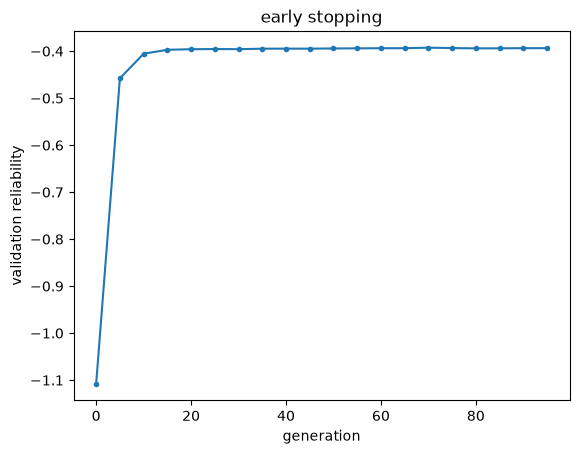

In [ ]:
gpu = GPURegressor(population=300, n_iter=400, early_stopping=True,
                   n_iter_no_change=5, check_every=5, random_state=0).fit(X, y)
print('stopped at iteration', gpu.n_iter_, '| best iteration', gpu.best_iteration_)
hist = gpu.history_
plt.plot([h['iteration'] for h in hist], [h['score'] for h in hist], '-o', ms=3)
plt.xlabel('generation'); plt.ylabel('validation crps'); plt.title('early stopping');

### Time-series cross-validation on a probabilistic score

In [3]:
scores = cross_val_score(GPURegressor(population=200, n_iter=40, random_state=0),
                         X, y, cv=TimeSeriesSplit(4), scoring=reliability_scorer)
print('reliability per fold:', np.round(scores, 3))

reliability per fold: [0.893 0.914 0.941 0.934]


### Search nested model / regularisation hyper-parameters

In [4]:
search = GridSearchCV(
    GPURegressor(model=MLPModel(), population=150, n_iter=30, random_state=0),
    {'model__n_hidden': [4, 8], 'reg_lambda': [0.0, 1e-3]},
    cv=TimeSeriesSplit(3), scoring=make_gpu_scorer('reliability'))
search.fit(X, y)
print('best params:', search.best_params_)

best params: {'model__n_hidden': 8, 'reg_lambda': 0.0}


`metric` (the training loss that shapes the front) and `scoring` (the held-out probabilistic criterion) are separate knobs — tune the front with `metric`, select and stop with `scoring`.